# Clinical Feature Analysis — QSVM Phase 1
**Task A — Prakshi**

Extract clinical features (CDR, MMSE, ASF, EDUC, SES), scale, reduce to 2 PCA components,
and save for multimodal QSVM training.

In [1]:
import pandas, numpy, matplotlib, seaborn, sklearn
print("all good")

all good


In [2]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
print("✅ All imports successful")

✅ All imports successful


In [3]:
# Cell 2 — Shared Dataset Loading Block
# ============================================================
# SHARED DATASET LOADING BLOCK
# Copy verbatim into clinical_qsvm.ipynb, mri_qsvm.ipynb,
# and speech_qsvm.ipynb — do not change anything here
# ============================================================
import pandas as pd
import numpy as np

df = pd.read_csv('data/multimodal_dementia_dataset.csv')

# Safety checks
# 24 features (clinical 4 + mri 2 + speech 18) + Subject_ID + Label = 26 columns.
# Row count is no longer fixed at 225 (real windowed match, re-runnable) -- check shape[1] only.
assert df.shape[1] == 26, f"Unexpected column count: {df.shape[1]}"
assert df.isnull().sum().sum() == 0, "NaNs found in dataset!"
assert df['Label'].isin([0, 1]).all(), "Invalid labels found!"

print(f"Dataset loaded: {df.shape}")
print(f"Label distribution: {df['Label'].value_counts()}")
print(f"Columns: {df.columns.tolist()}")
# ============================================================
# END SHARED LOADING BLOCK
# ============================================================

Dataset loaded: (233, 26)
Label distribution: Label
1    128
0    105
Name: count, dtype: int64
Columns: ['Subject_ID', 'MMSE', 'ASF', 'EDUC', 'SES', 'nWBV', 'eTIV', 'pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'Label']


In [4]:
# Cell 3 — Explore Clinical Features
CLINICAL_FEATURES = ['MMSE', 'ASF', 'EDUC', 'SES']  # CDR dropped -- OASIS Group is CDR-derived,
# so keeping it would re-inject the label (real_dataset_setup.md decision table).

print("=== CLINICAL FEATURE OVERVIEW ===")
print(df[CLINICAL_FEATURES].describe().round(3))
print(f"Null values: {df[CLINICAL_FEATURES].isnull().sum().to_dict()}")

print("=== PER-CLASS MEANS ===")
print(df.groupby('Label')[CLINICAL_FEATURES].mean().round(3))

=== CLINICAL FEATURE OVERVIEW ===
          MMSE      ASF     EDUC      SES
count  233.000  233.000  233.000  233.000
mean    26.710    1.187   14.442    2.507
std      4.191    0.134    2.920    1.098
min      4.000    0.881    6.000    1.000
25%     26.000    1.094   12.000    2.000
50%     28.000    1.186   14.000    2.309
75%     30.000    1.285   16.000    3.125
max     30.000    1.535   20.000    5.000
Null values: {'MMSE': 0, 'ASF': 0, 'EDUC': 0, 'SES': 0}
=== PER-CLASS MEANS ===
         MMSE    ASF    EDUC    SES
Label                              
0      29.171  1.193  15.114  2.334
1      24.691  1.182  13.891  2.649


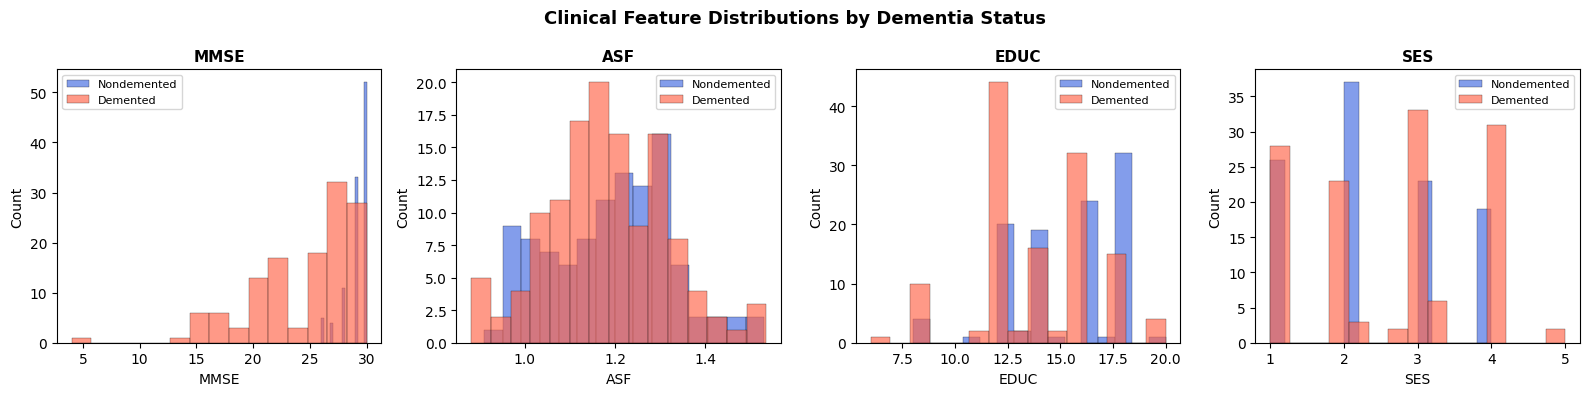

Saved: results/plots/clinical_feature_distributions.png


In [5]:
# Cell 4 — Feature Distribution Plots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = {0: 'royalblue', 1: 'tomato'}
label_names = {0: 'Nondemented', 1: 'Demented'}

for ax, feat in zip(axes, CLINICAL_FEATURES):
    for lbl in [0, 1]:
        ax.hist(df[df['Label']==lbl][feat],
                bins=15, alpha=0.65, color=colors[lbl],
                label=label_names[lbl], edgecolor='black', linewidth=0.3)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Clinical Feature Distributions by Dementia Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/clinical_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/plots/clinical_feature_distributions.png")

In [6]:
# Cell 5 — Select Features + Scale
X_clinical = df[CLINICAL_FEATURES].values
y = df['Label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clinical)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Mean after scaling (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std  after scaling (should be ~1): {X_scaled.std(axis=0).round(4)}")

Feature matrix shape: (233, 4)
Mean after scaling (should be ~0): [ 0. -0. -0. -0.]
Std  after scaling (should be ~1): [1. 1. 1. 1.]


Explained variance per component: [0.4966 0.255 ]
Total variance retained: 75.15%
Shape after PCA: (233, 2)


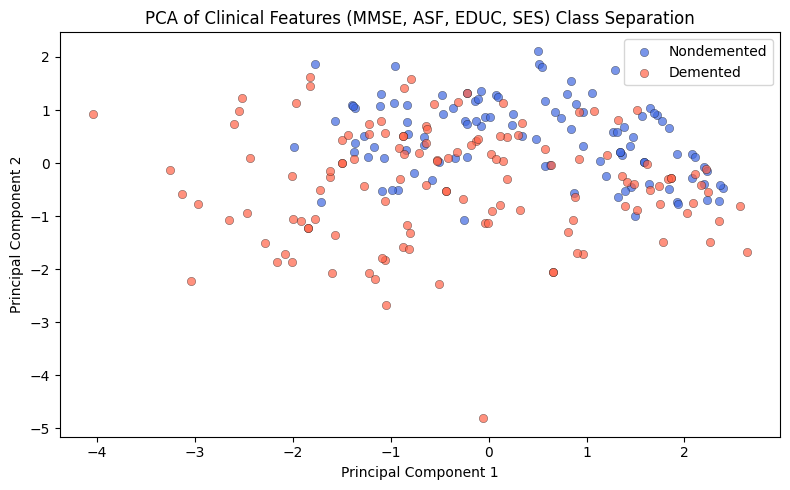

Saved: results/plots/clinical_pca.png


In [7]:
# Cell 6 — PCA Reduction to 2 Components
# Reduce 5 clinical features -> 2 principal components
# This is what gets passed to the QSVM (feature_dimension=2 per modality)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance per component: {pca.explained_variance_ratio_.round(4)}")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Shape after PCA: {X_pca.shape}")   # should be (N, 2), N = real assembled row count

# Visualize class separation in PCA space
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1],
            c='royalblue', label='Nondemented', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1],
            c='tomato', label='Demented', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Clinical Features (MMSE, ASF, EDUC, SES) Class Separation')
plt.legend()
plt.tight_layout()
plt.savefig('results/plots/clinical_pca.png', dpi=150)
plt.show()
print("Saved: results/plots/clinical_pca.png")

In [8]:
# Cell 7 — Save PCA Features + Labels
# Save the 2D PCA-compressed clinical features
# Shape must be (225, 2) — Prakshi's multimodal notebook will concatenate this
np.save('results/X_clinical_pca.npy', X_pca)

# y_labels saved ONCE here (all modalities share the same label vector)
np.save('results/y_labels.npy', y)

print(f"✅ Saved: results/X_clinical_pca.npy  — shape: {X_pca.shape}")
print(f"✅ Saved: results/y_labels.npy         — shape: {y.shape}")

# Sanity check
check_X = np.load('results/X_clinical_pca.npy')
check_y = np.load('results/y_labels.npy')
assert check_X.shape[1] == 2, f"Wrong shape: {check_X.shape}"
assert check_y.shape == (check_X.shape[0],), f"Wrong shape: {check_y.shape}"
print("✅ Reload check passed")
print(f"   X_clinical_pca: {check_X.shape}  |  y_labels: {check_y.shape}")

✅ Saved: results/X_clinical_pca.npy  — shape: (233, 2)
✅ Saved: results/y_labels.npy         — shape: (233,)
✅ Reload check passed
   X_clinical_pca: (233, 2)  |  y_labels: (233,)
